# 최종 모델 테스트 결과 (Final Result)

- **모델**: `models/final/model_final.joblib` (XGBClassifier)
- **테스트 데이터**: `data/preprocessed/X_test.csv`, `data/preprocessed/y_test.csv`
- 테스트셋에 대한 최종 성능 평가 결과를 정리

In [27]:
from pathlib import Path

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay,
)

ROOT = Path.cwd().parents[1]  # 프로젝트 루트 (models/final 기준)

model = joblib.load(ROOT / "models" / "final" / "model_final.joblib")
X_test = pd.read_csv(ROOT / "data" / "preprocessed" / "X_test.csv")
y_test = pd.read_csv(ROOT / "data" / "preprocessed" / "y_test.csv")["churn"]

print(type(model).__name__)
print("X_test:", X_test.shape, "/ y_test:", y_test.shape)

XGBClassifier
X_test: (864, 10) / y_test: (864,)


## 1. 예측 및 주요 성능 지표

테스트셋(864명)에 대해 예측을 수행하고 5가지 지표를 계산

| 지표 | 의미 (이 프로젝트 기준) |
|---|---|
| **Accuracy** | 전체 고객 중 이탈/유지를 맞게 분류한 비율 |
| **Precision** | "이탈"이라고 예측한 고객 중 실제로 이탈한 비율 (오탐이 적을수록 ↑) |
| **Recall** | 실제 이탈 고객 중 모델이 잡아낸 비율 — **이탈 예측에서 가장 중요** (놓치면 고객을 잃음) |
| **F1-score** | Precision과 Recall의 조화평균 (둘의 균형) |
| **ROC-AUC** | threshold와 무관한 모델의 종합 판별력 (1에 가까울수록 좋음, 0.5 = 랜덤) |

In [28]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

metrics = pd.DataFrame(
    {
        "Accuracy": [accuracy_score(y_test, y_pred)],
        "Precision": [precision_score(y_test, y_pred)],
        "Recall": [recall_score(y_test, y_pred)],
        "F1-score": [f1_score(y_test, y_pred)],
        "ROC-AUC": [roc_auc_score(y_test, y_proba)],
    },
    index=["XGBClassifier (final)"],
).round(4)
metrics

,Accuracy,Precision,Recall,F1-score,ROC-AUC
XGBClassifier (final),0.684,0.6591,0.7471,0.7003,0.7525


## 2. Classification Report

클래스(유지/이탈)별로 지표를 나눠서 보여줌
- `support` = 각 클래스의 실제 인원 수 (유지 437명 / 이탈 427명)
- **Churn(1) 행의 recall** 위주로 결과 확인

In [29]:
print(classification_report(y_test, y_pred, target_names=["Not Churn (0)", "Churn (1)"]))

               precision    recall  f1-score   support

Not Churn (0)       0.72      0.62      0.67       437
    Churn (1)       0.66      0.75      0.70       427

     accuracy                           0.68       864
    macro avg       0.69      0.68      0.68       864
 weighted avg       0.69      0.68      0.68       864



## 3. Confusion Matrix & ROC Curve

|  | 예측: 유지 | 예측: 이탈 |
|---|---|---|
| **실제 유지** | TN (정상) | FP (오탐 — 멀쩡한 고객을 이탈로 예측) |
| **실제 이탈** | **FN (놓침 — 가장 아까운 케이스)** | TP (잡아냄) |

> ⚠️ 여기서는 `model.predict()`의 **기본 threshold 0.5** 기준
>
> 팀 표준 threshold(0.38) 적용 결과는 **5번 섹션**확인
>
ROC Curve는 threshold를 0~1로 움직였을 때의 성능 궤적이며, 곡선 아래 면적이 AUC

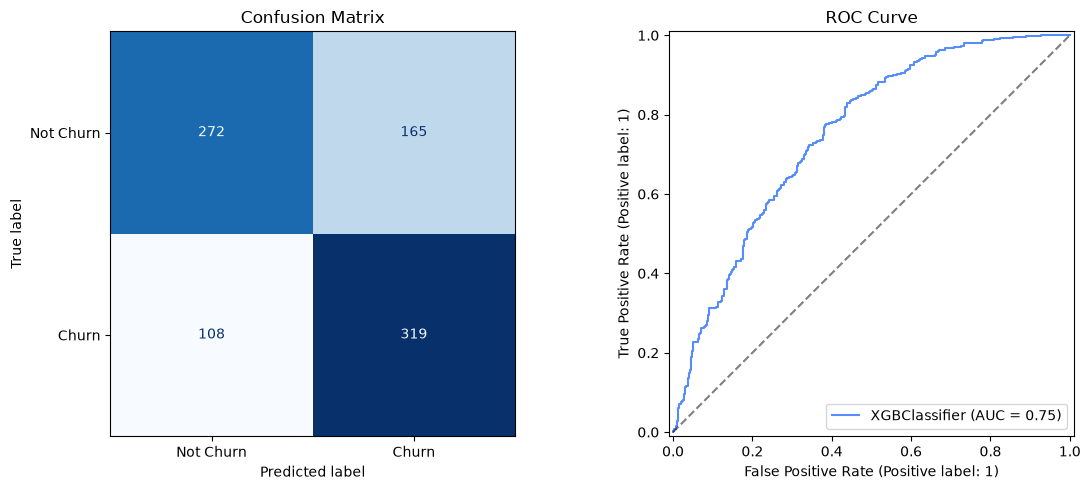

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not Churn", "Churn"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name="XGBClassifier")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()

## 4. 피처 중요도 (Feature Importance)

- 모델이 이탈 여부를 판단할 때 어떤 피처를 많이 참고했는지 시각화
- 막대가 길수록 예측에 크게 기여한 피처(모델 내부 기준의 상대적 중요도이며, 인과관계를 의미하지는 않음)

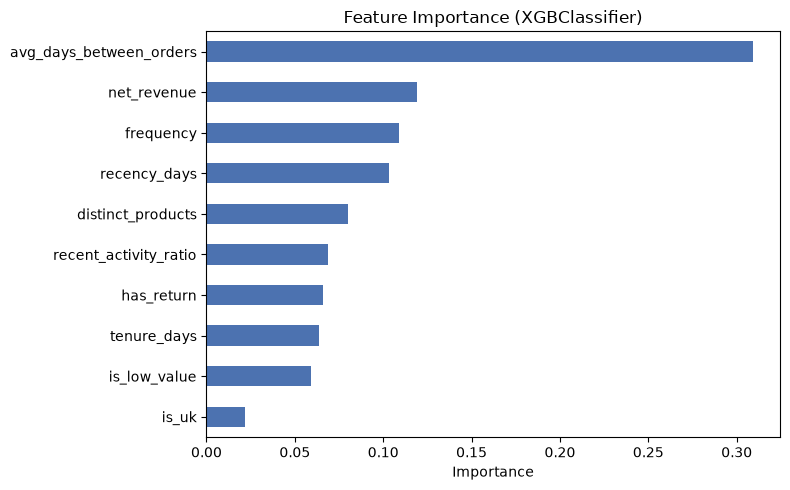

In [31]:
importance = (
    pd.Series(model.feature_importances_, index=X_test.columns)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot.barh(ax=ax, color="#4c72b0")
ax.set_title("Feature Importance (XGBClassifier)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 5. 팀 표준 Threshold(0.38) 기준 평가 — **최종 결과**

모델은 고객마다 "이탈 확률"을 출력하고, threshold(기준선)를 넘으면 이탈로 분류
- 기본값 0.5 대신 팀 표준 **0.38**을 적용
- 기준선을 낮추면 "조금이라도 의심되면 이탈로 분류"하게 되어 **놓치는 이탈 고객(FN)이 줄어드는 대신 오탐(FP)이 늘어남.**
- 이탈 예측은 고객을 놓치는 비용이 오탐(불필요한 리텐션 마케팅) 비용보다 크기 때문에 recall을 우선시함.
- **ROC-AUC는 threshold 적용 전 확률 자체의 판별력을 재는 지표**라서, threshold를 바꿔도 값이 변하지 않습니다 (두 행 동일).

In [32]:
THRESHOLD = 0.38  # streamlit_app/config.py DEFAULT_THRESHOLD

y_pred_038 = (y_proba >= THRESHOLD).astype(int)

metrics_038 = pd.DataFrame(
    {
        "Accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_038)],
        "Precision": [precision_score(y_test, y_pred), precision_score(y_test, y_pred_038)],
        "Recall": [recall_score(y_test, y_pred), recall_score(y_test, y_pred_038)],
        "F1-score": [f1_score(y_test, y_pred), f1_score(y_test, y_pred_038)],
        "ROC-AUC": [roc_auc_score(y_test, y_proba)] * 2,  # AUC는 threshold와 무관 → 동일
    },
    index=["threshold=0.50", "threshold=0.38 (팀 표준)"],
).round(4)
metrics_038

,Accuracy,Precision,Recall,F1-score,ROC-AUC
threshold=0.50,0.6840,0.6591,0.7471,0.7003,0.7525
threshold=0.38 (팀 표준),0.6794,0.6284,0.8595,0.7260,0.7525


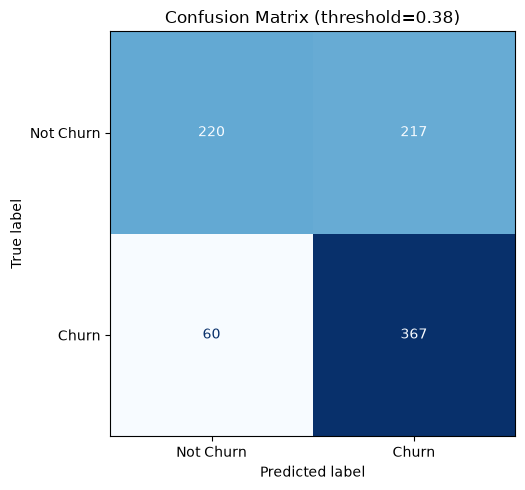

실제 이탈 427명 중 예측 성공 367명 / 놓침 60명


In [33]:
fig, ax = plt.subplots(figsize=(5.5, 5))
cm_038 = confusion_matrix(y_test, y_pred_038)
ConfusionMatrixDisplay(cm_038, display_labels=["Not Churn", "Churn"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Confusion Matrix (threshold=0.38)")
plt.tight_layout()
plt.show()

fn, tp = cm_038[1, 0], cm_038[1, 1]
print(f"실제 이탈 {fn + tp}명 중 예측 성공 {tp}명 / 놓침 {fn}명")

## 결론 요약

| | threshold 0.50 (기본) | **threshold 0.38 (팀 표준)** |
|---|---|---|
| Recall (이탈 잡은 비율) | 0.747 | **0.859** |
| Precision | 0.659 | 0.628 |
| F1-score | 0.700 | **0.726** |
| ROC-AUC | 0.7525 | 0.7525 (threshold와 무관하여 동일) |
| 놓친 이탈 고객 (FN) | 108명 | **60명** |
| 오탐 (FP) | 165명 | 217명 |

- **평가 기준은 Recall 우선**: 팀 표준 threshold 0.38 적용 시 실제 이탈 427명 중 **367명(85.9%)을 잡아냄** — 검증 때 Recall(0.857)이 테스트에서도 그대로 재현됨
- AUC(0.7525)**과적합 확인용**: threshold와 무관한 지표라 검증(0.7669) 대비 테스트 성능 유지 여부를 공정하게 비교 가능 → 과적합 없음
- 오탐 증가(165→217명)는 이탈 방지 마케팅 비용으로, 고객 유실 비용보다 작다고 판단하여 수용